### This code provides supports for results on Fairness Index, including those in Main Text section 2.4.

In [1]:
import sys
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon, Polygon
from shapely.ops import  unary_union
import math
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import ttest_ind, shapiro
from statsmodels.stats.multitest import multipletests

d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


state level

In [2]:
dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID',
            '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO',
            '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', 
            '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY', '60': 'AS', 
            '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}

col=['census_block_group','ParentType','num_accessible_facility','demand_ratios','demand_met_in_local']

listParentType=['Health Care Services',
                 'Pharmaceutical and Medical Supply Stores',
                 'Grocery and Food Supply',
                 'Social Assistance',
                 'Transportation Services',
                 'Home Health Care Services',
                 'Financial Services',
                 'Legal Services',
                 'Housing and Real Estate',
                 'Personal Care Services',
                 'Utility Services',
                 'Retail Stores for Basic Needs']


homoDistDiffFairList=[]


###data sources: census data and accratios
df_census = pd.read_csv('data/census/all_census_data_with_location.csv')
df_census['census_block_group']=df_census['census_block_group'].astype(str)
df_census_all=df_census[['census_block_group','percent_above_65']]



In [3]:
for key in listParentType: 
    homoPath='data/A under 5-mile setting/'+key+'.csv'
###data sources: census data and accratios 


    dfHomo=pd.read_csv(homoPath,usecols=col)
    dfHomo['census_block_group']=dfHomo['census_block_group'].astype(str)
    dfHomo=pd.merge(dfHomo,df_census_all)

    dfHomo['age']=dfHomo.apply(lambda x: 'greater than 0.5' if x['percent_above_65']>0.5 else 'mid',axis=1)
    dfHomo['age']=dfHomo.apply(lambda x: 'less than 0.2' if x['percent_above_65']<0.2 else x['age'],axis=1)

    dfHomo['statefip']=dfHomo.apply(lambda x: x['census_block_group'][0:2] if len(x['census_block_group'])==12 
                                     else x['census_block_group'][0:1],axis=1)

    print('read data_'+key)
    
    for fip in dict_state.keys():
        state=dict_state[fip]
        #print(state)
    #homo
        df_st=dfHomo[(dfHomo['statefip']==fip)&(dfHomo['age']!='mid')]

        if len(df_st)>0:
            numold=len(df_st[(df_st['age']=='greater than 0.5')&(df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']))
            if numold>0:     
                sumfair=0
                for i in range(9):
                    thres=np.percentile(df_st[(df_st['age']!='greater than 0.5')&
                                            (df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local'])['demand_met_in_local'],i*10+10)
                    numGood=len(df_st[(df_st['demand_met_in_local']>=thres)&(df_st['age']=='greater than 0.5')&
                                        (df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']) )     
                    fairindex=numGood/numold-(1-(i*10+10)/100)
                    sumfair += fairindex
                
                FairIndex=sumfair/4.5
                homoDistDiffFairList.append((key,state,FairIndex,'5 miles',numold))
         
    print('done'+key)    
    

    
homoDistDiffFairDF=pd.DataFrame(homoDistDiffFairList,columns=['parentType','state','FairIndex','coverage','numOldCBG'])


read data_Health Care Services
doneHealth Care Services
read data_Pharmaceutical and Medical Supply Stores
donePharmaceutical and Medical Supply Stores
read data_Grocery and Food Supply
doneGrocery and Food Supply
read data_Social Assistance
doneSocial Assistance
read data_Transportation Services
doneTransportation Services
read data_Home Health Care Services
doneHome Health Care Services
read data_Financial Services
doneFinancial Services
read data_Legal Services
doneLegal Services
read data_Housing and Real Estate
doneHousing and Real Estate
read data_Personal Care Services
donePersonal Care Services
read data_Utility Services
doneUtility Services
read data_Retail Stores for Basic Needs
doneRetail Stores for Basic Needs


In [4]:
homoDistDiffFairDF[(homoDistDiffFairDF['state'].isin(['FL','CA','AZ']))&( homoDistDiffFairDF['parentType'].isin(
    ['Health Care Services','Grocery and Food Supply','Housing and Real Estate'])  )]

,parentType,state,FairIndex,coverage,numOldCBG
1,Health Care Services,AZ,0.041363,5 miles,274
3,Health Care Services,CA,-0.075969,5 miles,215
7,Health Care Services,FL,0.146886,5 miles,851
94,Grocery and Food Supply,AZ,-0.084150,5 miles,272
96,Grocery and Food Supply,CA,-0.167186,5 miles,214
100,Grocery and Food Supply,FL,0.121780,5 miles,854
294,Housing and Real Estate,AZ,0.017843,5 miles,274
296,Housing and Real Estate,CA,-0.002537,5 miles,219
300,Housing and Real Estate,FL,0.142783,5 miles,856


In [5]:
for key in listParentType:
    md=np.median(homoDistDiffFairDF[(homoDistDiffFairDF['parentType']==key)&(homoDistDiffFairDF['numOldCBG']>=30)]['FairIndex'])
    print(key,md)

Health Care Services 0.09817938420348057
Pharmaceutical and Medical Supply Stores 0.036356764928193515
Grocery and Food Supply -0.08415032679738561
Social Assistance 0.30952380952380953
Transportation Services 0.5624999999999999
Home Health Care Services 0.43600562587904357
Financial Services 0.22843505791161642
Legal Services nan
Housing and Real Estate 0.03030303030303029
Personal Care Services 0.16712018140589568
Utility Services 0.7160493827160493
Retail Stores for Basic Needs -0.032094889237746387


d:\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [6]:
#save data
#homoDistDiffFairDF.to_csv('D:/main/1_research/P10_Mobility/p10_aging mobility/results_all_states/allStatesByParentType/FairIndex/homoDistDiffFairIndex_50_20.csv')


In [3]:
homoDistDiffFairDF=pd.read_csv('D:/main/1_research/P10_Mobility/p10_aging mobility/R1/new results/fairness/homoDistDiffFairIndex_50_20.csv')

country level

In [6]:
col=['census_block_group','ParentType','num_accessible_facility','demand_ratios','demand_met_in_local']

listParentType=['Health Care Services',
                 'Pharmaceutical and Medical Supply Stores',
                 'Grocery and Food Supply',
                 'Social Assistance',
                 'Transportation Services',
                 'Home Health Care Services',
                 'Financial Services',
                 'Legal Services',
                 'Housing and Real Estate',
                 'Personal Care Services',
                 'Utility Services',
                 'Retail Stores for Basic Needs']


homoDistDiffFairList=[]

###data sources: census data and accratios
for key in listParentType: 
    homoPath='data/A under 5-mile setting/'+key+'.csv'
    dfHomo=pd.read_csv(homoPath,usecols=col)
    dfHomo['census_block_group']=dfHomo['census_block_group'].astype(str)
    dfHomo=pd.merge(dfHomo,df_census_all)
###data sources: census data and accratios

    dfHomo['age']=dfHomo.apply(lambda x: 'greater than 0.5' if x['percent_above_65']>0.5 else 'mid',axis=1)
    dfHomo['age']=dfHomo.apply(lambda x: 'less than 0.2' if x['percent_above_65']<0.2 else x['age'],axis=1)
    
    dfHomo['statefip']=dfHomo.apply(lambda x: x['census_block_group'][0:2] if len(x['census_block_group'])==12 
                                     else x['census_block_group'][0:1],axis=1)
   
    print('read data_'+key)
     
#homo
    df_st=dfHomo[(dfHomo['age']!='mid')]
    if len(df_st)>0:
        numold=len(df_st[(df_st['age']=='greater than 0.5')&(df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']))
        if numold>0:     
            sumfair=0
            for i in range(9):
                thres=np.percentile(df_st[(df_st['age']!='greater than 0.5')&
                                        (df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local'])['demand_met_in_local'],i*10+10)
                numGood=len(df_st[(df_st['demand_met_in_local']>=thres)&(df_st['age']=='greater than 0.5')&
                                    (df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']) )     
                fairindex=numGood/numold-(1-(i*10+10)/100)
                sumfair += fairindex

            FairIndex=sumfair/4.5
            homoDistDiffFairList.append((key,'US',FairIndex,'5 miles',numold))
      
    print('done'+key)    

    
homoDDFairDF_US=pd.DataFrame(homoDistDiffFairList,columns=['parentType','state','FairIndex','coverage','numOldCBG'])


read data_Health Care Services
doneHealth Care Services
read data_Pharmaceutical and Medical Supply Stores
donePharmaceutical and Medical Supply Stores
read data_Grocery and Food Supply
doneGrocery and Food Supply
read data_Social Assistance
doneSocial Assistance
read data_Transportation Services
doneTransportation Services
read data_Home Health Care Services
doneHome Health Care Services
read data_Financial Services
doneFinancial Services
read data_Legal Services
doneLegal Services
read data_Housing and Real Estate
doneHousing and Real Estate
read data_Personal Care Services
donePersonal Care Services
read data_Utility Services
doneUtility Services
read data_Retail Stores for Basic Needs
doneRetail Stores for Basic Needs


In [4]:
#save data
#homoDDFairDF_US.to_csv('D:/main/1_research/P10_Mobility/p10_aging mobility/results_all_states/allStatesByParentType/FairIndex/homoDistDiffFairIndex_US_50_20.csv')

homoDDFairDF_US=pd.read_csv('D:/main/1_research/P10_Mobility/p10_aging mobility/R1/new results/fairness/homoDistDiffFairIndex_US_50_20.csv')

county level

In [8]:
abb_dict={'Health Care Services':'HCS','Grocery and Food Supply':'GFS', 'Housing and Real Estate':'HRE'}
homoDDall=[]
col=['census_block_group','ParentType','num_accessible_facility','demand_ratios','demand_met_in_local']

###data sources: census data and accratios
for key in abb_dict.keys():
    homoPath='data/A under 5-mile setting/'+key+'.csv'
    dfHomo=pd.read_csv(homoPath,usecols=col)
    dfHomo['census_block_group']=dfHomo['census_block_group'].astype(str)
    dfHomo=pd.merge(dfHomo,df_census_all)
###data sources: census data and accratios

    dfHomo['age']=dfHomo.apply(lambda x: 'greater than 0.5' if x['percent_above_65']>0.5 else 'mid',axis=1)
    dfHomo['age']=dfHomo.apply(lambda x: 'less than 0.2' if x['percent_above_65']<0.2 else x['age'],axis=1)
    
    dfHomo['countyfip']=dfHomo.apply(lambda x: x['census_block_group'][0:5] if len(x['census_block_group'])==12 
                                     else x['census_block_group'][0:4],axis=1) 



    for county in list(dfHomo['countyfip'].unique()):
        df_st=dfHomo[(dfHomo['countyfip']==county)&(dfHomo['age']!='mid')].dropna(subset=['demand_met_in_local'])

        numcbg=len(dfHomo[(dfHomo['countyfip']==county)])
        numold=len(df_st[df_st['age']=='greater than 0.5'])
        numyoung=len(df_st[df_st['age']!='greater than 0.5'])
        if (numold>0)& (numyoung>0):
            sumfair=0
            for i in range(9):
                thres = np.percentile(df_st[(df_st['age']!='greater than 0.5')&(df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local'])['demand_met_in_local'],i*10+10) 
                numGood = len(df_st[(df_st['demand_met_in_local']>=thres)&(df_st['age']=='greater than 0.5')&(df_st['demand_met_in_local']<=1)].dropna(subset=['demand_met_in_local']) )                         
                fairindex = numGood/numold-(1-(i*10+10)/100)
                sumfair += fairindex
            FairIndex = sumfair/4.5
            homoDDall.append((key,county,FairIndex,numold,numcbg,'5 miles'))
        print(county)
    print(key)

df_homoFairCounty=pd.DataFrame(homoDDall,columns=['parentType','county','FairIndex','num_old_cbg','num_cbg','coverage'])

df_homoFairCounty['old_percent']=df_homoFairCounty['num_old_cbg']/df_homoFairCounty['num_cbg']


1001
1003
1005
1007
1009
1011
1013
1015
1017
1019
1021
1023
1025
1027
1029
1031
1033
1035
1037
1039
1041
1043
1045
1047
1049
1051
1053
1055
1057
1059
1061
1063
1065
1067
1069
1071
1073
1075
1077
1079
1081
1083
1085
1087
1089
1091
1093
1095
1097
1099
1101
1103
1105
1107
1109
1111
1113
1115
1117
1119
1121
1123
1125
1127
1129
1131
1133
2013
2016
2020
2050
2060
2068
2070
2090
2100
2105
2110
2122
2130
2150
2158
2164
2170
2180
2185
2188
2195
2198
2220
2230
2240
2261
2275
2282
2290
4001
4003
4005
4007
4009
4011
4012
4013
4015
4017
4019
4021
4023
4025
4027
5001
5003
5005
5007
5009
5011
5013
5015
5017
5019
5021
5023
5025
5027
5029
5031
5033
5035
5037
5039
5041
5043
5045
5047
5049
5051
5053
5055
5057
5059
5061
5063
5065
5067
5069
5071
5073
5075
5077
5079
5081
5083
5085
5087
5089
5091
5093
5095
5097
5099
5101
5103
5105
5107
5109
5111
5113
5115
5117
5119
5121
5123
5125
5127
5129
5131
5133
5135
5137
5139
5141
5143
5145
5147
5149
6001
6003
6005
6007
6009
6011
6013
6015
6017
6019
6021
6023
6025
6027


In [9]:
df_census['county']=df_census['county'].astype(str)
df_tem=pd.DataFrame()
df_tem['county']=df_census['county'].unique()
df_tem['percent_above_65']=df_tem.apply(lambda x: sum(df_census[df_census['county']==x['county']]['above_65'])/sum(df_census[df_census['county']==x['county']]['population_by_age'])
                                        ,axis=1 )
df_homoFairCounty=pd.merge(df_homoFairCounty,df_tem,on='county',how='left')

In [5]:

#save data
#df_homoFairCounty.to_csv(r'D:\main\1_research\P10_Mobility\p10_aging mobility\R1\new results\fairness\countyFairIndex_50_20.csv')
df_homoFairCounty=pd.read_csv(r'D:\main\1_research\P10_Mobility\p10_aging mobility\R1\new results\fairness\countyFairIndex_50_20.csv')

In [6]:
homoDistDiffFairDF

,Unnamed: 0,parentType,state,FairIndex,coverage,numOldCBG
0,0,Health Care Services,AL,0.266667,5 miles,10
1,1,Health Care Services,AZ,0.041363,5 miles,274
2,2,Health Care Services,AR,0.042735,5 miles,13
3,3,Health Care Services,CA,-0.075969,5 miles,215
4,4,Health Care Services,CO,0.197531,5 miles,18
...,...,...,...,...,...,...
451,451,Retail Stores for Basic Needs,VA,-0.062500,5 miles,32
452,452,Retail Stores for Basic Needs,WA,0.174603,5 miles,28
453,453,Retail Stores for Basic Needs,WV,0.777778,5 miles,3
454,454,Retail Stores for Basic Needs,WI,0.266667,5 miles,10


In [7]:
df_homoFairCounty

,Unnamed: 0,parentType,county,FairIndex,num_old_cbg,num_cbg,coverage,old_percent,percent_above_65
0,0,Health Care Services,1003,-0.037037,3,94,5 miles,0.031915,0.187149
1,1,Health Care Services,1015,-0.777778,1,91,5 miles,0.010989,0.159307
2,2,Health Care Services,1073,0.777778,1,518,5 miles,0.001931,0.143101
3,3,Health Care Services,1077,0.111111,1,73,5 miles,0.013699,0.183126
4,4,Health Care Services,1089,0.777778,1,191,5 miles,0.005236,0.136679
...,...,...,...,...,...,...,...,...,...
1314,1314,Housing and Real Estate,72079,-0.111111,1,18,5 miles,0.055556,0.209637
1315,1315,Housing and Real Estate,72097,0.111111,1,70,5 miles,0.014286,0.207883
1316,1316,Housing and Real Estate,72113,0.000000,2,134,5 miles,0.014925,0.182530
1317,1317,Housing and Real Estate,72127,-0.777778,1,369,5 miles,0.002710,0.195673


In [6]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

dfDD=homoDistDiffFairDF
ftype='DistDiff'
g2=dfDD[(dfDD['numOldCBG']>=30)&(dfDD['parentType']=='Grocery and Food Supply')]['FairIndex']
g3=dfDD[(dfDD['numOldCBG']>=30)&(dfDD['parentType']=='Housing and Real Estate')]['FairIndex']
g1=dfDD[(dfDD['numOldCBG']>=30)&(dfDD['parentType']=='Health Care Services')]['FairIndex']
# 原始p值列表（两两比较）
comparisons = [('HCS', 'GFS', g1, g2), ('HCS', 'HRE', g1, g3), ('GFS', 'HRE', g2, g3)]
raw_pvals = [ttest_ind(a, b, equal_var=False).pvalue for _, _, a, b in comparisons]

# 多重比较校正（Holm 方法）
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='holm')

# 正态性检验
for label, group in [('HCS', g1), ('GFS', g2), ('HRE', g3)]:
    stat, p = shapiro(group)
    print(f'{label} Shapiro-Wilk p = {"<0.001" if p < 0.001 else round(p, 3)}')

# 显示结果
def sig(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

dd_dict_pvalue={}
for i, (name1, name2, _, _) in enumerate(comparisons):
    
    r'$\mathit{p}$={"<0.001" '
    if raw_pvals[i] < 0.001: 
        dd_dict_pvalue[(name1, name2)]=r'$\mathit{p}$<0.001'
    else: 
        dd_dict_pvalue[(name1, name2)]=r'$\mathit{p}$='+str(round(raw_pvals[i], 3))
    print(f'{name1} vs {name2}:')
    print(f'  Raw p = {"<0.001" if raw_pvals[i] < 0.001 else round(raw_pvals[i], 3)}')
    print(f'  Corrected p (Holm) = {"<0.001" if corrected_pvals[i] < 0.001 else round(corrected_pvals[i], 3)}')
    print(f'  Significance: {sig(corrected_pvals[i])}')

HCS Shapiro-Wilk p = 0.999
GFS Shapiro-Wilk p = 0.445
HRE Shapiro-Wilk p = 0.606
HCS vs GFS:
  Raw p = 0.038
  Corrected p (Holm) = 0.113
  Significance: n.s.
HCS vs HRE:
  Raw p = 0.363
  Corrected p (Holm) = 0.363
  Significance: n.s.
GFS vs HRE:
  Raw p = 0.121
  Corrected p (Holm) = 0.242
  Significance: n.s.


In [16]:
#figg.savefig(r"D:\main\1_research\P10_Mobility\p10_aging mobility\R1\new results\fairness\county_DD_fairindex_HGH_3states_with_percentabove65_50_20.jpg",dpi=600)  

In [16]:
dfa=homoDistDiffFairDF[(homoDistDiffFairDF['numOldCBG']>=30)&(homoDistDiffFairDF['parentType'].isin(['Health Care Services','Grocery and Food Supply', 'Housing and Real Estate']))][['parentType','state','FairIndex','numOldCBG']].rename(columns={'parentType':'service_type','FairIndex':'fairnes_index','numOldCBG':'number_HighAging_CBG'})

In [7]:
dd_dict_pvalue

{('HCS', 'GFS'): '$\\mathit{p}$=0.038',
 ('HCS', 'HRE'): '$\\mathit{p}$=0.363',
 ('GFS', 'HRE'): '$\\mathit{p}$=0.121'}

C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\2951671246.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfD2['state']=pd.Categorical(dfD2['state'],categories=stateList,ordered=True)
C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\2951671246.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\2951671246.py:132: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFr

Health Care Services -0.002951973058947852 0.16513229299553078
Grocery and Food Supply 0.012458328114407727 0.006789634189741829


C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\2951671246.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\2951671246.py:132: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = results.params[0]
C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\2951671246.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\

Housing and Real Estate 0.0155860755416749 0.12841960313050832


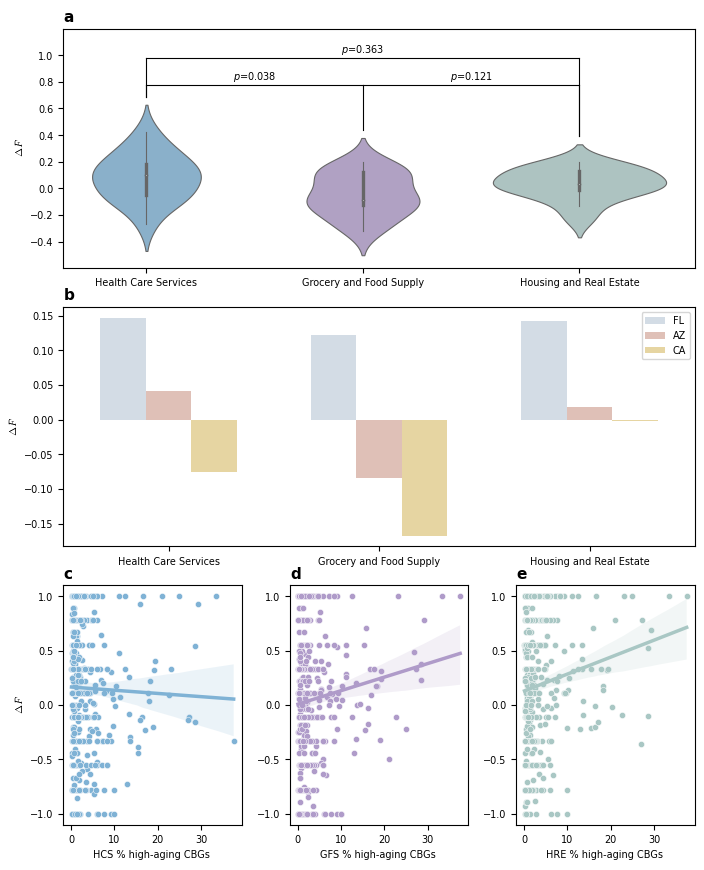

In [24]:
width_in_inches = 180 * 0.0393701
height_in_inches =width_in_inches/9*11

figg=plt.figure(figsize=(width_in_inches,height_in_inches))
fig=gridspec.GridSpec(3,3)



ax0=plt.subplot(fig[0,:3])
ax1=plt.subplot(fig[1,:3])

ax=[ax0,ax1]

mainPType=['Health Care Services','Grocery and Food Supply', 'Housing and Real Estate']
type_color_dict={'Health Care Services':'#7FB2D5','Grocery and Food Supply':'#AF9BC9', 'Housing and Real Estate':'#A9C7C4'}

dfD=homoDistDiffFairDF[(homoDistDiffFairDF['numOldCBG']>=30)&(homoDistDiffFairDF['parentType'].isin(mainPType))]
#fig, ax=plt.subplots(2,1,constrained_layout=True, figsize=(8, 8))#

HGHlist=['HCS','GFS','HRE']

hue='DistDiff'

lwd=0.8
s=sns.violinplot(x='parentType',y='FairIndex',data=dfD,split=False,ax=ax[0],
                 palette=type_color_dict.values(),linewidth=lwd) #,cut=-1

#ax[0].axhline(0,color='red',linestyle='dashed')
s.set_xlabel('')
#s.set_title(hue)

loc_dict={}
for j, violin in enumerate(s.collections):
    if j%2==0:
        vertices = violin.get_paths()[0].vertices
        top_position_y = vertices[:, 1].max()
        top_position_x = vertices[0, 0].mean()
        loc_dict[HGHlist[j//2]+'_'+hue]=(top_position_x,top_position_y)
        
dic_pv=dd_dict_pvalue


x1=0#loc_dict['HCS_'+hue][0]

y1=max(loc_dict['HCS_'+hue][1],loc_dict['GFS_'+hue][1],loc_dict['HRE_'+hue][1])+0.15
x2=1#loc_dict['GFS_'+hue][0]
y2=y1

x3=2#loc_dict['HRE_'+hue][0]
y3=max(loc_dict['HCS_'+hue][1],loc_dict['GFS_'+hue][1],loc_dict['HRE_'+hue][1])+0.35


ax[0].plot([x1,x2],[y1,y2],color='black',linewidth=lwd)
ax[0].plot([x3,x2],[y1,y1],color='black',linewidth=lwd)

ax[0].plot([x3,x1],[y3,y3],color='black',linewidth=lwd)

ax[0].plot([x1,x1],[loc_dict['HCS_'+hue][1]+0.06,y3],color='black',linewidth=lwd)
ax[0].plot([x3,x3],[loc_dict['HRE_'+hue][1]+0.06,y3],color='black',linewidth=lwd)    

ax[0].plot([x1,x1],[loc_dict['HCS_'+hue][1]+0.06,y1],color='black',linewidth=lwd)
ax[0].plot([x2,x2],[loc_dict['GFS_'+hue][1]+0.06,y1],color='black',linewidth=lwd)

ax[0].plot([x3,x3],[loc_dict['HRE_'+hue][1]+0.06,y1],color='black',linewidth=lwd)


ax[0].text((x1+x2)/2,y1+0.04,dic_pv[('HCS', 'GFS')],ha='center',fontsize=7)
ax[0].text((x3+x2)/2,y1+0.04,dic_pv[( 'GFS','HRE')],ha='center',fontsize=7)

ax[0].text((x1+x3)/2,y3+0.04,dic_pv[('HCS', 'HRE')],ha='center',fontsize=7)

ax[0].plot([x3,x1],[y3+0.05,y3+0.05],color='white')
  
ax[0].set_ylabel(r'$\Delta \bar F$',usetex=True,fontsize=7)
#r'$\Delta \bar F$',usetex=True,
ax[0].set_yticks([-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0])
ax[0].set_ylim(-0.6, 1.2)
ax[0].tick_params(axis='both', which='both', bottom=True, left=True,labelsize=7) 
#sub image2
mainPType=['Health Care Services',
                'Grocery and Food Supply',
                 'Housing and Real Estate']

#stateList=['US','FL','AZ','CA']
stateList=['FL','AZ','CA']
#state_color_dict={'US':'#98A3CA','FL':'#D0DCE8', 'AZ':'#E6BCB0','CA':'#F2DB96'}
state_color_dict={'FL':'#D0DCE8', 'AZ':'#E6BCB0','CA':'#F2DB96'}

color_dict={'Health Care Services':'#7FB2D5','Grocery and Food Supply':'#AF9BC9', 'Housing and Real Estate':'#A9C7C4'}


dfD2=homoDistDiffFairDF[(homoDistDiffFairDF['numOldCBG']>=30)&(homoDistDiffFairDF['parentType'].isin(mainPType))
          &(homoDistDiffFairDF['state'].isin(stateList))]

dfD2['state']=pd.Categorical(dfD2['state'],categories=stateList,ordered=True)
dfD2= dfD2.sort_values(by='state')


sns.barplot(x='parentType',y='FairIndex',hue='state',palette=state_color_dict,data=dfD2,ax=ax[1],width=0.65)
ax[1].legend(title=None, fontsize=7)
ax[1].set_xlabel('')
ax[1].set_ylabel(r'$\Delta \bar F$',usetex=True,fontsize=7)
ax[1].tick_params(axis='both', which='both', bottom=True, left=True,labelsize=7)  #

abb_dict={'Health Care Services':'HCS','Grocery and Food Supply':'GFS', 'Housing and Real Estate':'HRE'}
size_dict={0:20,10: 60 ,30: 180}

color_dict={'Health Care Services':'#7FB2D5','Grocery and Food Supply':'#AF9BC9', 'Housing and Real Estate':'#A9C7C4'}
mainPType=color_dict.keys()


ax2_list = []
for j, key in enumerate(mainPType): #key='Health Care Services'
    k=0
    ax2=plt.subplot(fig[2,j])
    ax2_list.append(ax2)
    dfD=df_homoFairCounty[(df_homoFairCounty['num_old_cbg']>k)&(df_homoFairCounty['parentType'].isin(mainPType))]
    dfD['old_percent']=dfD['old_percent']*100
    s=sns.scatterplot(x='old_percent',y='FairIndex',data=dfD[(dfD['parentType']==key)&(dfD['old_percent']>=0.0)],ax=ax2,
                      color=color_dict[key],s=20,alpha=1)
    s=sns.regplot(data=dfD[(dfD['parentType']==key)&(dfD['old_percent']>=0.0)], x="old_percent", y='FairIndex',
                   scatter=False, ax=ax2,color=color_dict[key],line_kws={"linewidth": 2.5})
    
    #regression
    data=dfD[(dfD['parentType']==key)&(dfD['old_percent']>=0.0)]
    x = data['old_percent']
    y = data['FairIndex']
    x_with_constant = sm.add_constant(x)  
    model = sm.OLS(y, x_with_constant)
    results = model.fit()
    slope = results.params[1]
    intercept = results.params[0]
    print(key,slope,intercept)


    #s.set_title(abb_dict[key])
    ax2.set_ylim(-1.1, 1.1)
    if j>0:
        ax2.set_ylabel('')
    else:
        ax2.set_ylabel(r'$\Delta \bar F$',usetex=True,fontsize=7)
    ax2.set_yticks([-1.0,-0.5,0,0.5,1])
    #ax2.set_xticks([0.0,0.1,0.2])
    
    ax2.set_xlabel(abb_dict[key]+' % high-aging CBGs ',fontsize=7)
    ax2.tick_params(axis='both', which='both', bottom=True, left=True,labelsize=7)  

# 添加 a, b, c, d, e 标签
labels = ['a', 'b', 'c', 'd', 'e']
axes_list = [ax[0], ax[1]] + ax2_list  # 合并所有子图的 axes 对象
for i, ax_i in enumerate(axes_list):
    if i<2:
        ax_i.text(-0.0, 1.08, labels[i], transform=ax_i.transAxes, fontsize=11, fontweight='bold', va='top', ha='left')
    else:
        ax_i.text(-0.0, 1.08, labels[i], transform=ax_i.transAxes, fontsize=11, fontweight='bold', va='top', ha='left')

plt.subplots_adjust(hspace=5) 
figg.tight_layout()

In [25]:
figg.savefig(r'D:\main\1_research\P10_Mobility\p10_aging mobility\R1\new results\fairness\county_DD_fairindex_HGH_3states_with_oldpercent_50_20.pdf', dpi=300, bbox_inches='tight', format='pdf')

C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\927883042.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfD2['state'] = pd.Categorical(dfD2['state'], categories=stateList, ordered=True)
C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\927883042.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\927883042.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataF

Health Care Services -0.002951973058947852 0.16513229299553078
Grocery and Food Supply 0.012458328114407727 0.006789634189741829


C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\927883042.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\927883042.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = results.params[0]
C:\Users\Linao\AppData\Local\Temp\ipykernel_46576\927883042.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[1]
C:\Users\Lin

Housing and Real Estate 0.0155860755416749 0.12841960313050832


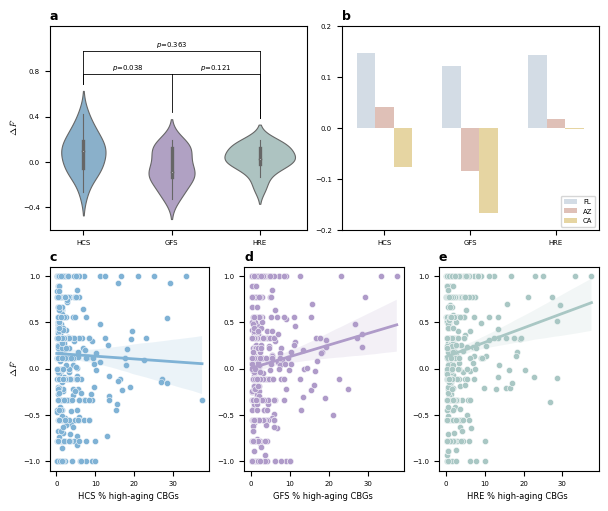

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm

# 计算图表尺寸
width_in_inches = 180 * 0.0393701
height_in_inches = width_in_inches / 9 * 11 * 2 / 3

# 创建 Figure 和 GridSpec
fig = plt.figure(figsize=(width_in_inches, height_in_inches))
gs = fig.add_gridspec(2, 6, wspace=0.56, hspace=0.18)  # 调整 wspace 和 hspace

# 第一行子图
ax0 = fig.add_subplot(gs[0, :3])  # 占前三列
ax1 = fig.add_subplot(gs[0, 3:])  # 占后三列
ax = [ax0, ax1]

# 第二行子图
ax2_list = [fig.add_subplot(gs[1, 0:2]),  # 占第1-2列
            fig.add_subplot(gs[1, 2:4]),  # 占第3-4列
            fig.add_subplot(gs[1, 4:6])]  # 占第5-6列

# 定义颜色字典
mainPType = ['Health Care Services', 'Grocery and Food Supply', 'Housing and Real Estate']
type_color_dict = {'Health Care Services': '#7FB2D5', 'Grocery and Food Supply': '#AF9BC9', 'Housing and Real Estate': '#A9C7C4'}
stateList = ['FL', 'AZ', 'CA']
state_color_dict = {'FL': '#D0DCE8', 'AZ': '#E6BCB0', 'CA': '#F2DB96'}
abb_dict = {'Health Care Services': 'HCS', 'Grocery and Food Supply': 'GFS', 'Housing and Real Estate': 'HRE'}

# 数据过滤
dfD = homoDistDiffFairDF[(homoDistDiffFairDF['numOldCBG'] >= 30) & (homoDistDiffFairDF['parentType'].isin(mainPType))]
dfD2 = homoDistDiffFairDF[(homoDistDiffFairDF['numOldCBG'] >= 30) & (homoDistDiffFairDF['parentType'].isin(mainPType)) &
                          (homoDistDiffFairDF['state'].isin(stateList))]
dfD2['state'] = pd.Categorical(dfD2['state'], categories=stateList, ordered=True)
dfD2 = dfD2.sort_values(by='state')

# 第一行子图1：小提琴图
hue = 'DistDiff'
lwd = 0.8
s = sns.violinplot(x='parentType', y='FairIndex', data=dfD, split=False, ax=ax[0],
                   palette=type_color_dict.values(), linewidth=lwd)
s.set_xlabel('')
ax[0].set_ylabel(r'$\Delta \bar F$', usetex=True, fontsize=6)
ax[0].set_yticks([-0.4, 0.0, 0.4, 0.8])
ax[0].set_ylim(-0.6, 1.2)
ax[0].tick_params(axis='both', which='both', bottom=True, left=True, labelsize=5)

lwd = 0.6
# 添加显著性线和文本
loc_dict = {}
for j, violin in enumerate(s.collections):
    if j % 2 == 0:
        vertices = violin.get_paths()[0].vertices
        top_position_y = vertices[:, 1].max()
        top_position_x = vertices[0, 0].mean()
        loc_dict[HGHlist[j // 2] + '_' + hue] = (top_position_x, top_position_y)

x1, x2, x3 = 0, 1, 2  # 简化坐标
y1 = max(loc_dict['HCS_' + hue][1], loc_dict['GFS_' + hue][1], loc_dict['HRE_' + hue][1]) + 0.15
y3 = y1 + 0.2
ax[0].plot([x1, x2], [y1, y1], color='black', linewidth=lwd)
ax[0].plot([x3, x2], [y1, y1], color='black', linewidth=lwd)
ax[0].plot([x1, x3], [y3, y3], color='black', linewidth=lwd)
ax[0].plot([x1, x1], [loc_dict['HCS_' + hue][1] + 0.06, y3], color='black', linewidth=lwd)
ax[0].plot([x3, x3], [loc_dict['HRE_' + hue][1] + 0.06, y3], color='black', linewidth=lwd)
ax[0].plot([x1, x1], [loc_dict['HCS_' + hue][1] + 0.06, y1], color='black', linewidth=lwd)
ax[0].plot([x2, x2], [loc_dict['GFS_' + hue][1] + 0.06, y1], color='black', linewidth=lwd)
ax[0].plot([x3, x3], [loc_dict['HRE_' + hue][1] + 0.06, y1], color='black', linewidth=lwd)

ax[0].text((x1 + x2) / 2, y1 + 0.04, dic_pv[('HCS', 'GFS')], ha='center', fontsize=5)
ax[0].text((x3 + x2) / 2, y1 + 0.04, dic_pv[('GFS', 'HRE')], ha='center', fontsize=5)
ax[0].text((x1 + x3) / 2, y3 + 0.04, dic_pv[('HCS', 'HRE')], ha='center', fontsize=5)

# 第一行子图2：柱状图
sns.barplot(x='parentType', y='FairIndex', hue='state', palette=state_color_dict, data=dfD2, ax=ax[1], width=0.65)
ax[1].legend(title=None, fontsize=5, loc='lower right', bbox_to_anchor=(1, 0))
ax[1].set_xlabel('')
ax[1].set_ylabel("")
ax[1].set_yticks([-0.2, -0.1, 0.0, 0.1, 0.2])
ax[1].set_ylim(-0.2, 0.2)
ax[1].tick_params(axis='both', which='both', bottom=True, left=True, labelsize=5)

# 替换 x 轴标签
for i in [0, 1]:
    xticklabels = [tick.get_text() for tick in ax[i].get_xticklabels()]
    new_labels = [abb_dict.get(label, label) for label in xticklabels]
    ax[i].set_xticklabels(new_labels, fontsize=5)

# 第二行子图：散点图和回归线
for j, key in enumerate(mainPType):
    ax2 = ax2_list[j]
    dfD = df_homoFairCounty[(df_homoFairCounty['num_old_cbg'] > 0) & (df_homoFairCounty['parentType'].isin(mainPType))]
    dfD['old_percent'] = dfD['old_percent'] * 100
    sns.scatterplot(x='old_percent', y='FairIndex', data=dfD[(dfD['parentType'] == key) & (dfD['old_percent'] >= 0.0)],
                    ax=ax2, color=color_dict[key], s=20, alpha=1)
    sns.regplot(data=dfD[(dfD['parentType'] == key) & (dfD['old_percent'] >= 0.0)], x="old_percent", y='FairIndex',
                scatter=False, ax=ax2, color=color_dict[key], line_kws={"linewidth": 2.0})

    # OLS 回归
    data = dfD[(dfD['parentType'] == key) & (dfD['old_percent'] >= 0.0)]
    x = data['old_percent']
    y = data['FairIndex']
    x_with_constant = sm.add_constant(x)
    model = sm.OLS(y, x_with_constant)
    results = model.fit()
    slope = results.params[1]
    intercept = results.params[0]
    print(key, slope, intercept)

    ax2.set_ylim(-1.1, 1.1)
    ax2.set_yticks([-1.0, -0.5, 0, 0.5, 1])
    ax2.set_xlabel(abb_dict[key] + ' % high-aging CBGs ', fontsize=6)
    ax2.tick_params(axis='both', which='both', bottom=True, left=True, labelsize=5)
    if j>0:
        ax2.set_ylabel('')
    else:
        ax2.set_ylabel(r'$\Delta \bar F$',usetex=True,fontsize=6)

# 添加 a, b, c, d, e 标签
labels = ['a', 'b', 'c', 'd', 'e']
axes_list = [ax[0], ax[1]] + ax2_list
for i, ax_i in enumerate(axes_list):
    ax_i.text(-0.0, 1.08, labels[i], transform=ax_i.transAxes, fontsize=9, fontweight='bold', va='top', ha='left')

# 优化布局
plt.tight_layout()


In [78]:
fig.savefig(r'D:\main\1_research\P10_Mobility\p10_aging mobility\R1\new results\fairness\fig5_v2_3.pdf', dpi=300, bbox_inches='tight', format='pdf')

In [19]:
mainPType=['Health Care Services','Grocery and Food Supply', 'Housing and Real Estate']
df_cde=df_homoFairCounty[(df_homoFairCounty['num_old_cbg']>0)&(df_homoFairCounty['parentType'].isin(mainPType))][['parentType','county','FairIndex','old_percent']].rename(columns={
    'parentType':'service_type','county':'county_fip','FairIndex':'fairness_index','old_percent':'ratio_of_HighAging_CBG'
    })

In [21]:
dfa

,service_type,state,fairnes_index,number_HighAging_CBG
1,Health Care Services,AZ,0.041363,274
3,Health Care Services,CA,-0.075969,215
7,Health Care Services,FL,0.146886,851
10,Health Care Services,IL,0.423423,37
17,Health Care Services,MD,0.311111,40
18,Health Care Services,MA,-0.105105,37
19,Health Care Services,MI,0.007407,30
25,Health Care Services,NV,0.255556,40
27,Health Care Services,NJ,-0.266055,109
29,Health Care Services,NY,0.089692,83


In [20]:
df_cde

,service_type,county_fip,fairness_index,ratio_of_HighAging_CBG
0,Health Care Services,1003,-0.037037,0.031915
1,Health Care Services,1015,-0.777778,0.010989
2,Health Care Services,1073,0.777778,0.001931
3,Health Care Services,1077,0.111111,0.013699
4,Health Care Services,1089,0.777778,0.005236
...,...,...,...,...
1314,Housing and Real Estate,72079,-0.111111,0.055556
1315,Housing and Real Estate,72097,0.111111,0.014286
1316,Housing and Real Estate,72113,0.000000,0.014925
1317,Housing and Real Estate,72127,-0.777778,0.002710


In [ ]:
#with pd.ExcelWriter('SourceData_Fig5.xlsx') as writer:
#    dfa.to_excel(writer, sheet_name='Fig5a_b', index=False)
#    df_cde.to_excel(writer, sheet_name='Fig5c-e', index=False)